In [9]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt 

from Vares import EVT_var, historical_var, parametric_var_normal
import Vares

In [10]:
_ = pd.read_excel('hist.xlsx').to_numpy()
prices_usd = _[:, -2]

def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = np.array(rets, dtype='float64')
    return rets 

original_returns_usd  = return_array(prices_usd)
original_returns_usd_scaled = original_returns_usd * 100

log_returns_usd = np.log(1 + original_returns_usd)
log_returns_usd_scaled = log_returns_usd * 100 

# Rolling parameters
window = 365 #calendar year 
alpha = 0.01  

rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

In [44]:
import pickle

with open('prices_usd.pkl', 'wb') as f: 
    pickle.dump(prices_usd, f)

with open('original_returns_usd.pkl', 'wb') as f: 
    pickle.dump(original_returns_usd, f)

with open('log_returns_usd.pkl', 'wb') as f: 
    pickle.dump(log_returns_usd, f)

In [11]:
Vares.ENABLE_TIMING = False

In [12]:
EVT_var(original_returns_usd_scaled[1000:1365])

IMPORTANT 18 365 0.750240855460267 0.2417556084228047 0


Array(2.58019452, dtype=float64)

In [13]:
#simple 1 day VaR 
lag = 365 #calendar year
time_series_length = original_returns_usd.shape[0]
avialable_lenth = time_series_length - lag

historical_vars_99 = [0]*lag
parametric_vars_99 = [0]*lag
EVT_vars_99 = [0]*lag
historical_vars_95 = [0]*lag
parametric_vars_95 = [0]*lag
EVT_vars_95 = [0]*lag

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    historical_vars_99.append(historical_var(returns_sliced, alpha=0.01))
    historical_vars_95.append(historical_var(returns_sliced, alpha=0.05))
    parametric_vars_99.append(parametric_var_normal(returns_sliced, alpha=0.01))
    parametric_vars_95.append(parametric_var_normal(returns_sliced, alpha=0.05))
    # EVT_vars_99.append(EVT_var(returns_sliced, alpha=0.01))
    # EVT_vars_95.append(EVT_var(returns_sliced, alpha=0.05))


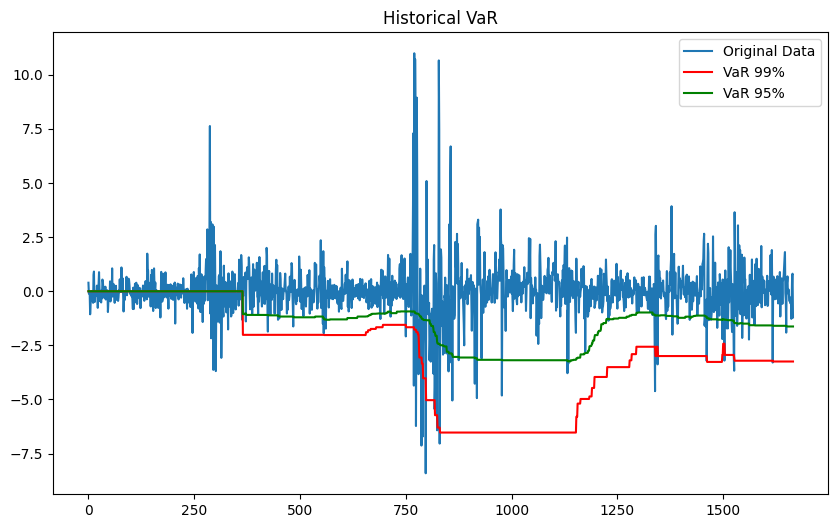

In [14]:
historical_vars_99_ = [-1 * _ for _ in historical_vars_99]
historical_vars_95_ = [-1 * _ for _ in historical_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(historical_vars_99_, color='red', label='VaR 99%')
plt.plot(historical_vars_95_, color='green', label='VaR 95%')
plt.title('Historical VaR')
plt.legend()
plt.show()


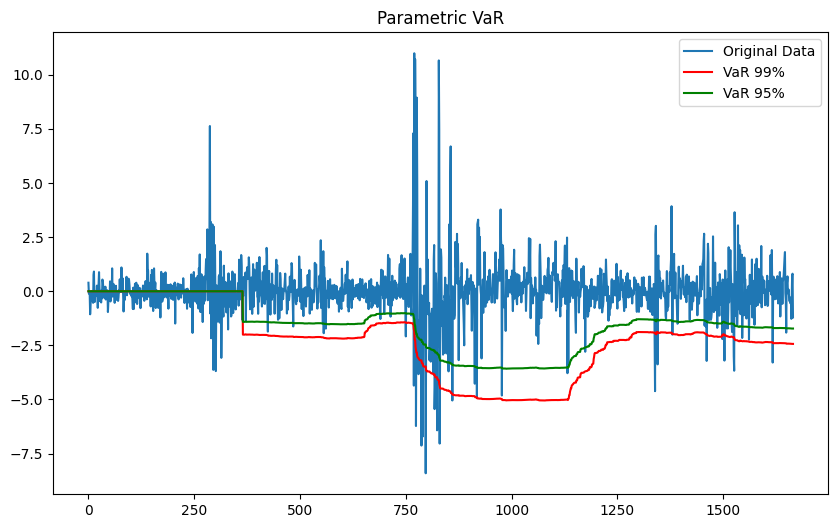

In [15]:
parametric_vars_99_ = [-1 * _ for _ in parametric_vars_99]
parametric_vars_95_ = [-1 * _ for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(parametric_vars_99_, color='red', label='VaR 99%')
plt.plot(parametric_vars_95_, color='green', label='VaR 95%')
plt.title('Parametric VaR')
plt.legend()
plt.show()

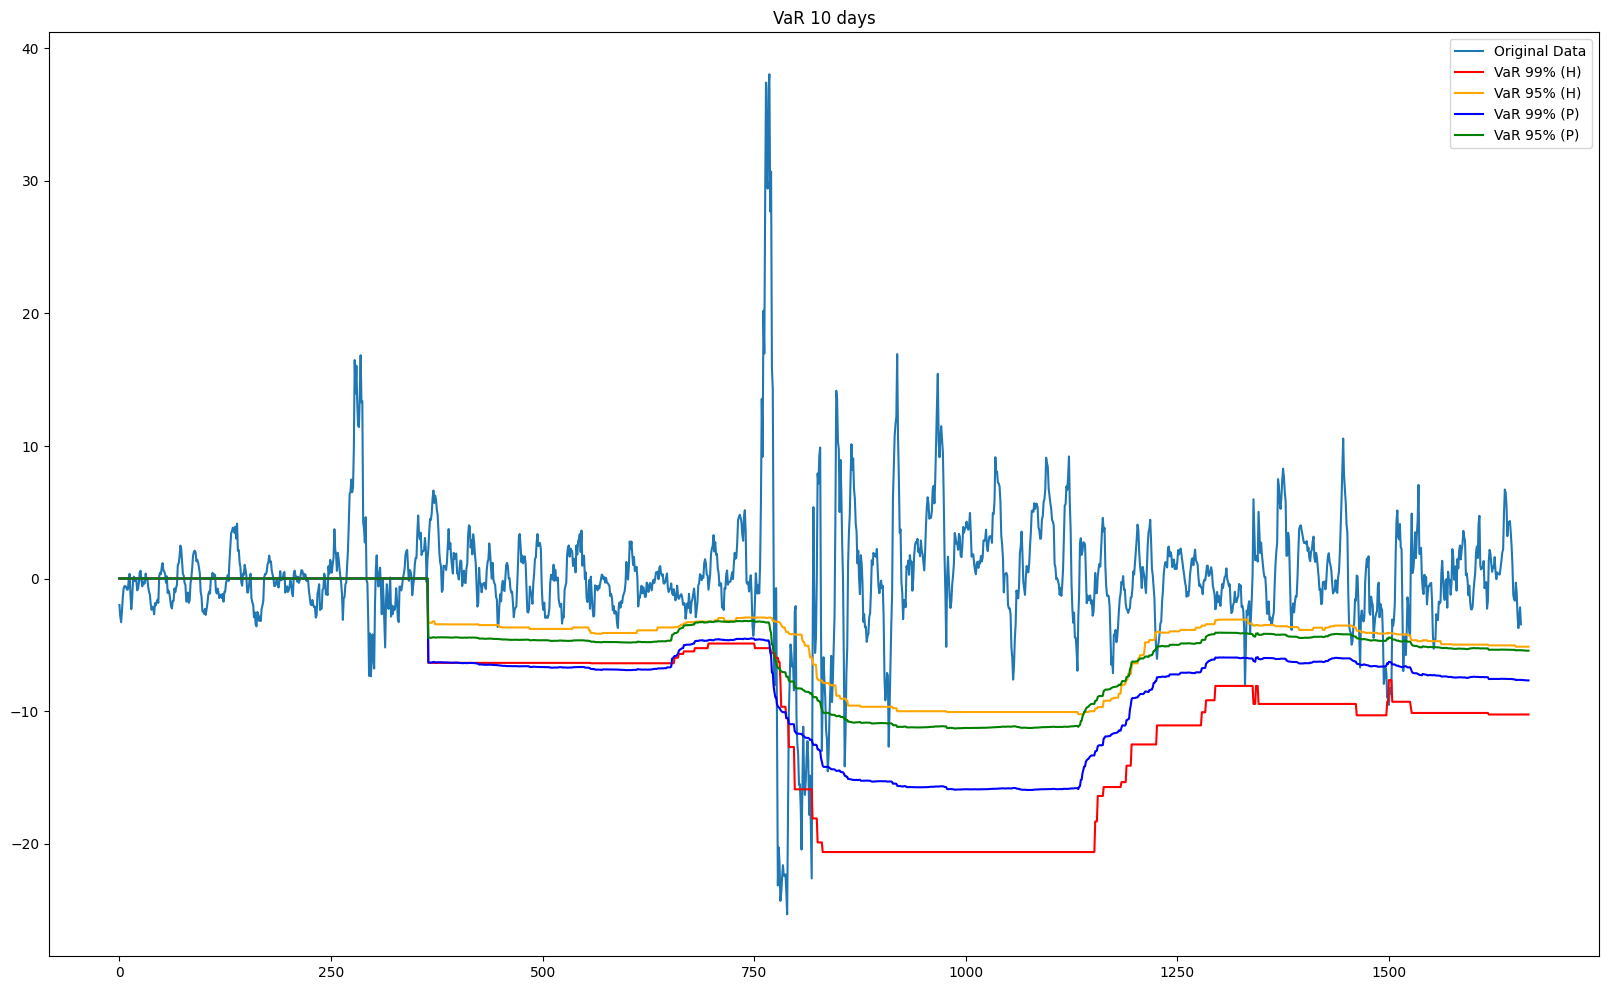

In [17]:
window = 10
cummulative_log_returns = np.convolve(log_returns_usd_scaled, np.ones(window), mode='valid')

historical_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_99]
historical_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in historical_vars_95]

parametric_vars_99_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_99]
parametric_vars_95_10 = [-1 * _ * np.sqrt(10) for _ in parametric_vars_95]

# Plot original data and fitted values
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original Data')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)')
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)')
plt.title('VaR 10 days')
plt.legend()
plt.show()


EVT VaR

In [35]:
from Vares import MLE_EVT

def EVT_VaR_w_cutoff(returns, alpha=0.01, u_level = 0.95, return_details = False): 
    """
    EVT VaR assuming tail follow GPD (Generalized Paretto Distribution).

    For details refer to Hull, J. (2012). Risk management and financial institutions  / John C. Hull. (3rd ed.). John Wiley. Equation (12.9)
    """
    result, u, n_u = MLE_EVT(returns, u_level=u_level, mode_var=True)

    xi = result.x[0]
    _log_beta = result.x[1]
    beta = jnp.exp(_log_beta)

    nominator = beta/xi 
    power = xi * (-1)
    n = returns.shape[0]

    # print('IMPORTANT', n_u, n, beta, xi, result.status)

    VaR = u + nominator*(((n / n_u * alpha)**(power)) - 1)  
    if nominator < 0: 
        return u

    if return_details is True: 
        return VaR, result, u, [beta, xi] #allows for detailed results analysis

    return VaR 

In [36]:
EVT_VaRs = [0] * 365

for t in range(avialable_lenth): 
    returns_sliced = log_returns_usd_scaled[t:t+365]
    EVT_VaRs.append(EVT_VaR_w_cutoff(returns_sliced, alpha=0.01))

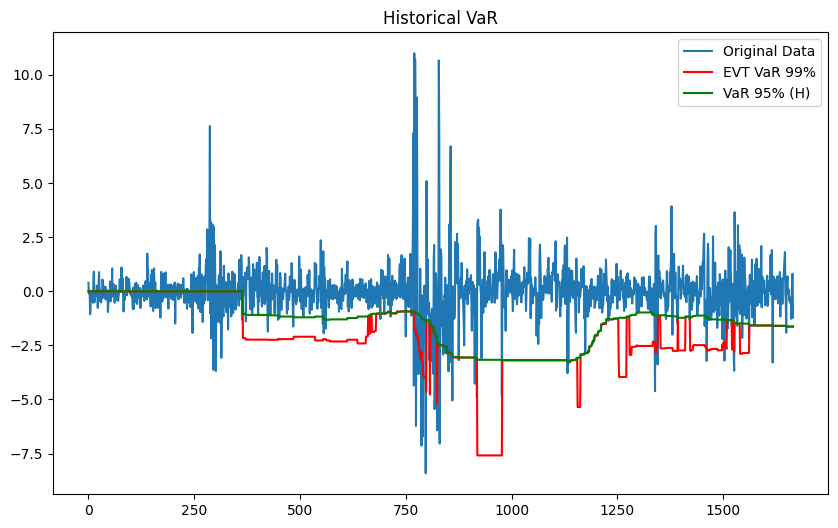

In [38]:
EVT_VaRs_neg = np.negative(EVT_VaRs)

# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(log_returns_usd_scaled, label='Original Data')
plt.plot(EVT_VaRs_neg, color='red', label='EVT VaR 99%')
plt.plot(historical_vars_95_, color='green', label='VaR 95% (H)')
plt.title('Historical VaR')
plt.legend()
plt.show()


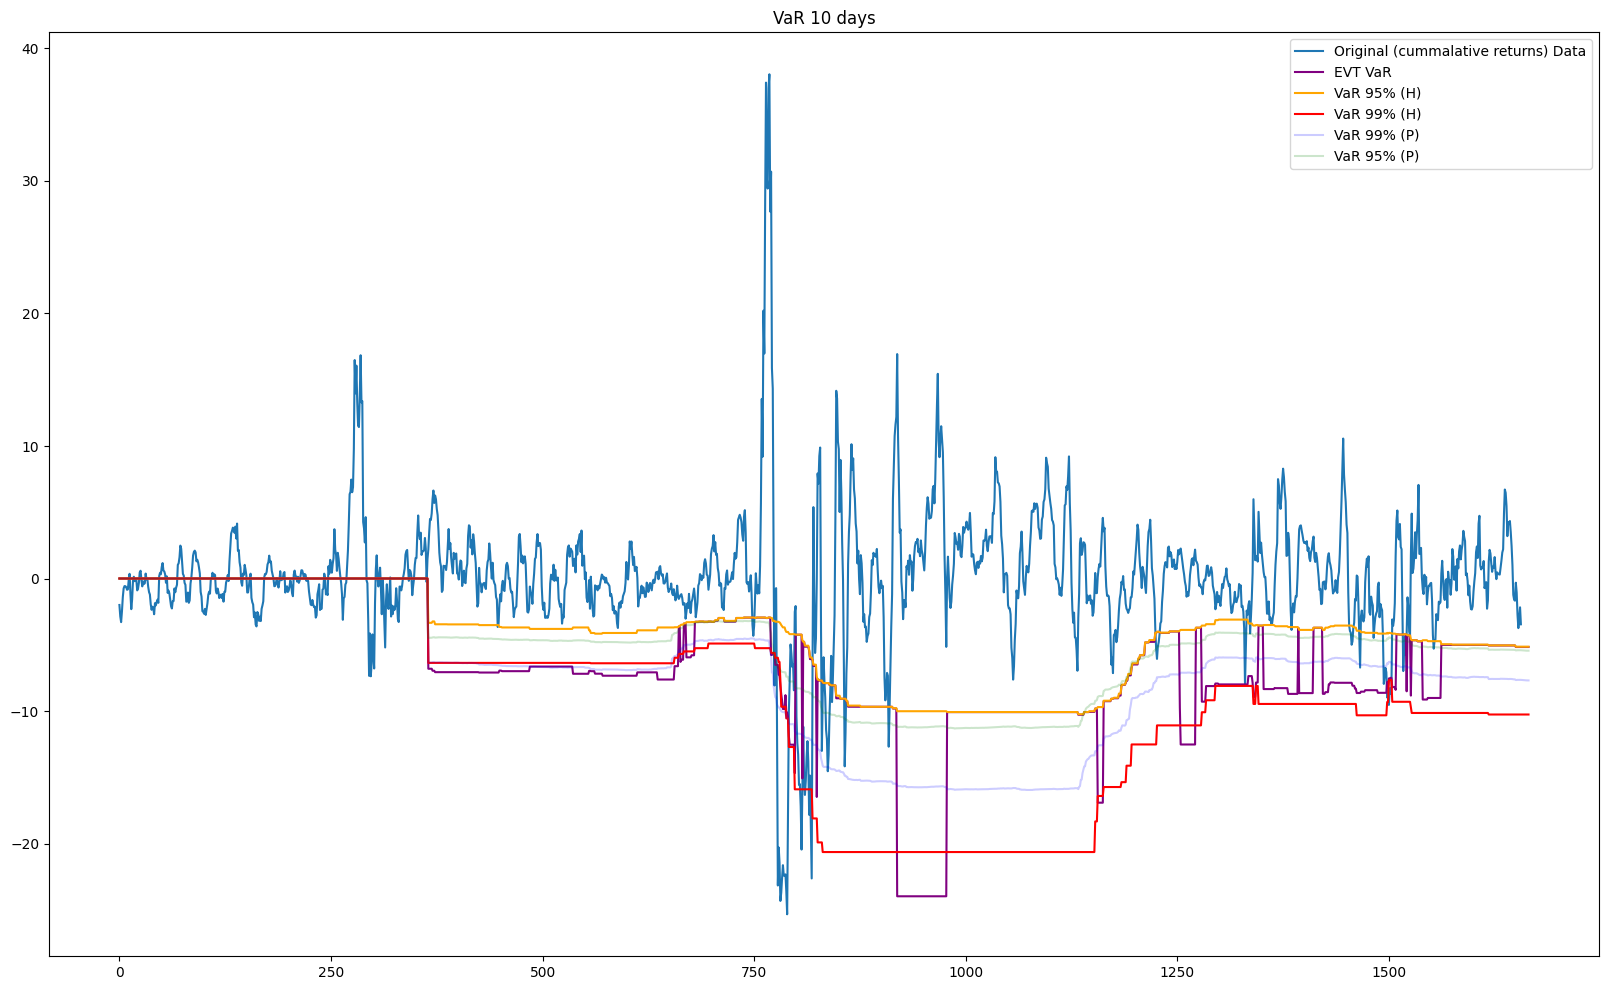

In [39]:
EVT_VaRs_neg_10 = EVT_VaRs_neg * np.sqrt(10)

plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original (cummalative returns) Data')
plt.plot(EVT_VaRs_neg_10, color='purple', label='EVT VaR')
plt.plot(historical_vars_95_10, color='orange', label='VaR 95% (H)')
plt.plot(historical_vars_99_10, color='red', label='VaR 99% (H)')
plt.plot(parametric_vars_99_10, color='blue', label='VaR 99% (P)', alpha=0.2)
plt.plot(parametric_vars_95_10, color='green', label='VaR 95% (P)', alpha=0.2)
plt.title('VaR 10 days')
plt.legend()
plt.show()

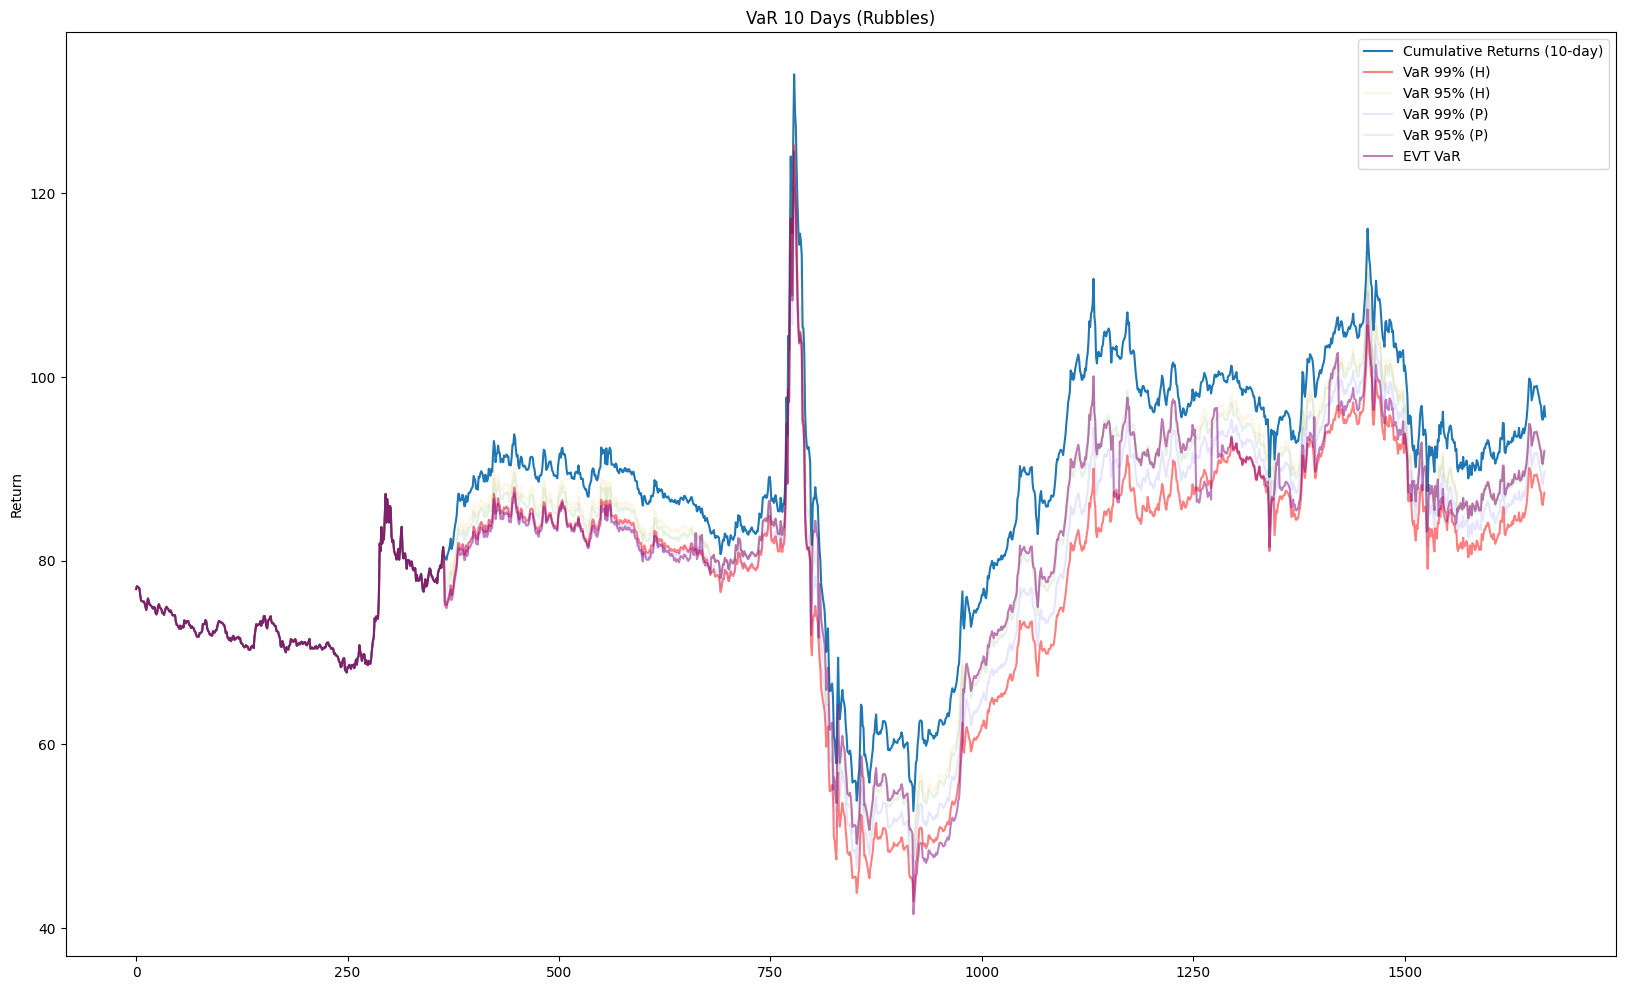

In [ ]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(historical_vars_99_10, prices_usd), color='red', label='VaR 99% (H)', alpha=0.5)
plt.plot(turn_var_into_real_terms(historical_vars_95_10, prices_usd), color='orange', label='VaR 95% (H)', alpha=0.1)
plt.plot(turn_var_into_real_terms(parametric_vars_99_10, prices_usd), color='blue', label='VaR 99% (P)', alpha=0.1)
plt.plot(turn_var_into_real_terms(parametric_vars_95_10, prices_usd), color='green', label='VaR 95% (P)', alpha=0.1)
plt.plot(turn_var_into_real_terms(EVT_VaRs_neg_10, prices_usd), color='purple', label='EVT VaR', alpha=0.5)
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('Return')
plt.legend()
plt.show()